# Molten Pot — Tiny Demo Walkthrough

This notebook walks through the **`moltenpot-tiny`** companion dataset:
five small HDF5 files, one per substrate, each containing two episodes
from a randomly chosen scenario in that substrate. It is intended to
let reviewers inspect the data layout and field-of-view observations
without downloading the full ~1 TB corpus.

The notebook is organised as:

1. **Setup** — install dependencies, download the tiny dataset.
2. **Per-substrate walkthrough** — for each substrate, list the
   episodes, print summary statistics, plot per-step reward curves,
   plot the action distribution, and render the focal-agent
   field-of-view (FoV) at a few timesteps.
3. **Cross-substrate summary** — episode-return distributions
   compared across the five substrates.

**Dataset schema** (per episode group inside `dataset.hdf5`):

| Key       | Shape              | Dtype   | Meaning |
|-----------|--------------------|---------|---------|
| `obs`     | `(T, A, 3, 88, 88)` | uint8  | RGB first-person view per focal agent per step |
| `actions` | `(T, A)`           | int32   | discrete action per focal agent per step |
| `rewards` | `(T, A)`           | float32 | per-focal-agent per-step reward |
| `dones`   | `(T,)`             | bool    | episode-done flag (one-hot terminal step) |

`T` is the episode length (≤ 1000), `A` the number of focal agents in
that scenario (1–14 depending on the substrate).


## 1. Setup


In [1]:
# Install runtime dependencies (this cell is a no-op if already present).
# Falls back gracefully across pip / uv-pip environments.
import sys, subprocess
def _ensure(pkgs):
    missing = []
    for p in pkgs:
        try: __import__(p.split("==")[0].replace("-", "_"))
        except ImportError: missing.append(p)
    if not missing: return
    cmd = [sys.executable, "-m", "pip", "install", "--quiet", *missing]
    try:
        subprocess.check_call(cmd)
    except (FileNotFoundError, subprocess.CalledProcessError):
        # uv-managed venvs do not ship the legacy `pip` module; try uv.
        subprocess.check_call(["uv", "pip", "install", *missing])

_ensure(["h5py", "numpy", "matplotlib", "huggingface_hub"])

In [2]:
import os, logging, h5py, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

# Quiet HF Hub: its progress bars and info logs print absolute cache
# paths, which would leak the local username into committed notebook
# output. We resolve datasets silently and print only repo-relative
# paths via ``display_path`` below.
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
os.environ.setdefault("HF_HUB_DISABLE_TELEMETRY", "1")
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)

# Tiny-demo data lives under the ``tiny-demo-datasets/`` subdirectory of
# the same Hugging Face dataset that holds the full corpus. The notebook
# resolves a local path per substrate, falling back to the Hub when not
# already cached.
HF_REPO_ID  = "jcformanek/moltenpot"
HF_PREFIX   = "tiny-demo-datasets"
LOCAL_DEMO  = Path("../data/tiny-demo-datasets")  # relative to notebooks/

SUBSTRATES = ["coins", "coop_mining", "clean_up",
              "commons_harvest", "allelopathic_harvest"]

In [3]:
# Resolve a local dataset.hdf5 path per substrate, downloading from
# Hugging Face on demand if needed.
def resolve_dataset(substrate: str):
    """Return a local Path to <substrate>/<scenario>/dataset.hdf5,
    or None if neither the local cache nor the HF Hub yields one.

    Strategy:
      1. If the file already lives under LOCAL_DEMO, use it.
      2. Otherwise fetch the matching path from HF_REPO_ID.
    """
    if LOCAL_DEMO.exists():
        for scen_dir in (LOCAL_DEMO / substrate).glob("*"):
            ds = scen_dir / "dataset.hdf5"
            if ds.is_file():
                return ds

    try:
        from huggingface_hub import HfApi, hf_hub_download
        api = HfApi()
        files = api.list_repo_files(HF_REPO_ID, repo_type="dataset")
    except Exception as exc:
        print(f"[{substrate}] HF lookup failed: {exc}")
        return None

    prefix = f"{HF_PREFIX}/{substrate}/"
    candidates = [f for f in files
                  if f.startswith(prefix) and f.endswith("dataset.hdf5")]
    if not candidates:
        return None
    local = hf_hub_download(
        repo_id=HF_REPO_ID, filename=candidates[0], repo_type="dataset"
    )
    return Path(local)


def display_path(p):
    """Strip the HF cache prefix so we never print absolute filesystem
    paths (which would leak the sandbox username) in committed notebook
    output. Returns the repo-relative path under HF_PREFIX."""
    if p is None: return "<not found>"
    parts = p.parts
    if HF_PREFIX in parts:
        i = parts.index(HF_PREFIX)
        return f"{HF_REPO_ID}:{Path(*parts[i:])}"
    try:
        return str(p.relative_to(LOCAL_DEMO.resolve().parent))
    except ValueError:
        return p.name


for s in SUBSTRATES:
    p = resolve_dataset(s)
    print(f"  {s:>22s} -> {display_path(p)}")

                   coins -> jcformanek/moltenpot:tiny-demo-datasets/coins/coins_6/dataset.hdf5


             coop_mining -> jcformanek/moltenpot:tiny-demo-datasets/coop_mining/coop_mining_3/dataset.hdf5


                clean_up -> jcformanek/moltenpot:tiny-demo-datasets/clean_up/clean_up_13/dataset.hdf5


         commons_harvest -> jcformanek/moltenpot:tiny-demo-datasets/commons_harvest/commons_harvest__closed_0/dataset.hdf5


    allelopathic_harvest -> jcformanek/moltenpot:tiny-demo-datasets/allelopathic_harvest/allelopathic_harvest__open_4/dataset.hdf5


## 2. Per-substrate walkthrough

For each substrate we open the HDF5 file, list its episodes, summarise
the trajectory dimensions and reward, then make three small plots:

* **per-step reward** for one focal agent, both episodes overlaid;
* **action histogram** across both episodes;
* **field-of-view frames** sampled at four points across one episode.

The FoV frames are exactly what the policy sees: the focal agent's
ego-centric RGB observation, padded to a fixed 88×88 grid.


In [4]:
def load_episode(scen_grp, ep_key):
    ep = scen_grp[ep_key]
    return {
        "obs":     ep["obs"][...],        # (T, A, 3, 88, 88) uint8
        "actions": ep["actions"][...],    # (T, A) int32
        "rewards": ep["rewards"][...],    # (T, A) float32
        "dones":   ep["dones"][...],      # (T,) bool
    }


def summarise(substrate, path):
    print(f"=== {substrate.upper():^60s} ===")
    print(f"file: {display_path(path)}")
    print(f"size on disk: {path.stat().st_size / 1024:.1f} KB")
    with h5py.File(path, "r") as f:
        scen_keys = list(f.keys())
        print(f"scenario(s): {scen_keys}")
        for scen in scen_keys:
            grp = f[scen]
            ep_keys = sorted(grp.keys(), key=lambda k: int(k.split("_")[1]))
            print(f"  {scen}: {len(ep_keys)} episodes ({ep_keys})")
            for ep_k in ep_keys:
                ep = grp[ep_k]
                T, A = ep["actions"].shape
                ret = ep["rewards"][...].sum(axis=0)  # per-agent return
                print(f"    {ep_k}: T={T:4d} A={A:2d}  "
                      f"focal-agent returns={np.round(ret, 2).tolist()}")

In [5]:
def plot_substrate_panel(substrate, path):
    with h5py.File(path, "r") as f:
        scen = list(f.keys())[0]
        grp = f[scen]
        ep_keys = sorted(grp.keys(), key=lambda k: int(k.split("_")[1]))
        eps = [load_episode(grp, k) for k in ep_keys]

    fig = plt.figure(figsize=(13, 4.2))
    fig.suptitle(f"{substrate} — {scen}", fontsize=13, fontweight="bold")

    # (a) per-step reward, focal agent 0, both episodes overlaid
    ax = fig.add_subplot(1, 3, 1)
    for i, ep in enumerate(eps):
        ax.plot(ep["rewards"][:, 0], lw=0.9, alpha=0.85,
                label=f"episode {ep_keys[i]}")
    ax.set_title("Per-step reward (focal agent 0)")
    ax.set_xlabel("step"); ax.set_ylabel("reward")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # (b) action histogram across both episodes
    ax = fig.add_subplot(1, 3, 2)
    all_a = np.concatenate([ep["actions"].ravel() for ep in eps])
    n_actions = int(all_a.max()) + 1
    ax.hist(all_a, bins=np.arange(n_actions + 1) - 0.5,
            color="steelblue", edgecolor="white")
    ax.set_xticks(np.arange(n_actions))
    ax.set_title("Action distribution")
    ax.set_xlabel("action id"); ax.set_ylabel("count")
    ax.grid(axis="y", alpha=0.3)

    # (c) FoV frames at four timesteps from episode 0, focal agent 0
    ax = fig.add_subplot(1, 3, 3)
    ep0 = eps[0]
    T = ep0["obs"].shape[0]
    ts = np.linspace(0, T - 1, 4, dtype=int)
    frames = [np.transpose(ep0["obs"][t, 0], (1, 2, 0)) for t in ts]
    panel = np.concatenate(frames, axis=1)
    ax.imshow(panel)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"FoV frames at t={list(ts)} (focal agent 0)")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

===                            COINS                             ===
file: jcformanek/moltenpot:tiny-demo-datasets/coins/coins_6/dataset.hdf5
size on disk: 960.2 KB
scenario(s): ['coins_6']
  coins_6: 2 episodes (['ep_0', 'ep_1'])
    ep_0: T=1000 A= 1  focal-agent returns=[-75.0]
    ep_1: T= 899 A= 1  focal-agent returns=[-68.0]


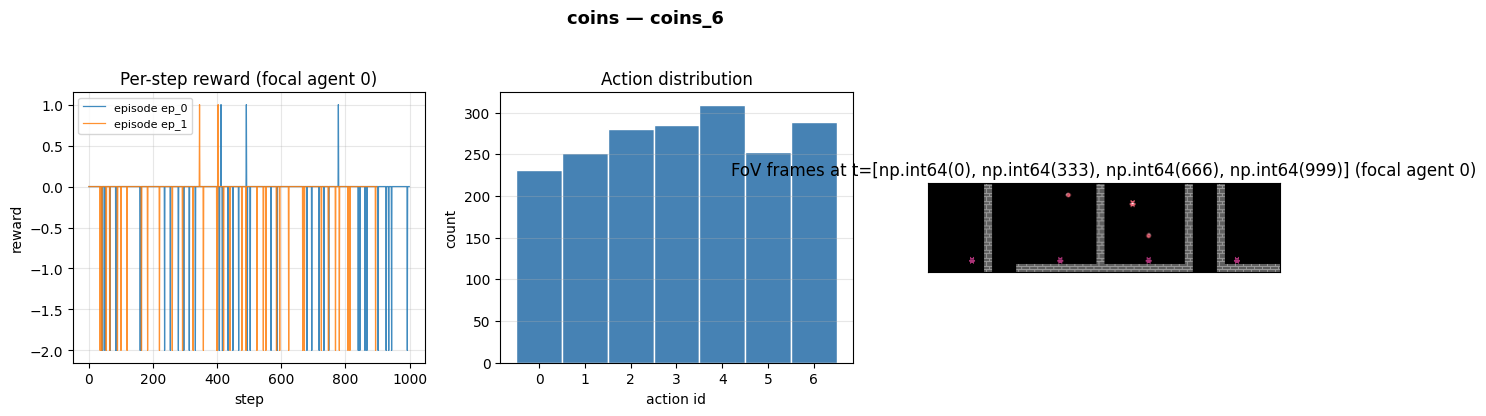

===                         COOP_MINING                          ===
file: jcformanek/moltenpot:tiny-demo-datasets/coop_mining/coop_mining_3/dataset.hdf5
size on disk: 8048.7 KB
scenario(s): ['coop_mining_3']
  coop_mining_3: 2 episodes (['ep_0', 'ep_1'])
    ep_0: T=1000 A= 5  focal-agent returns=[7.0, 17.0, 13.0, 9.0, 38.0]
    ep_1: T=1000 A= 5  focal-agent returns=[6.0, 9.0, 23.0, 11.0, 15.0]


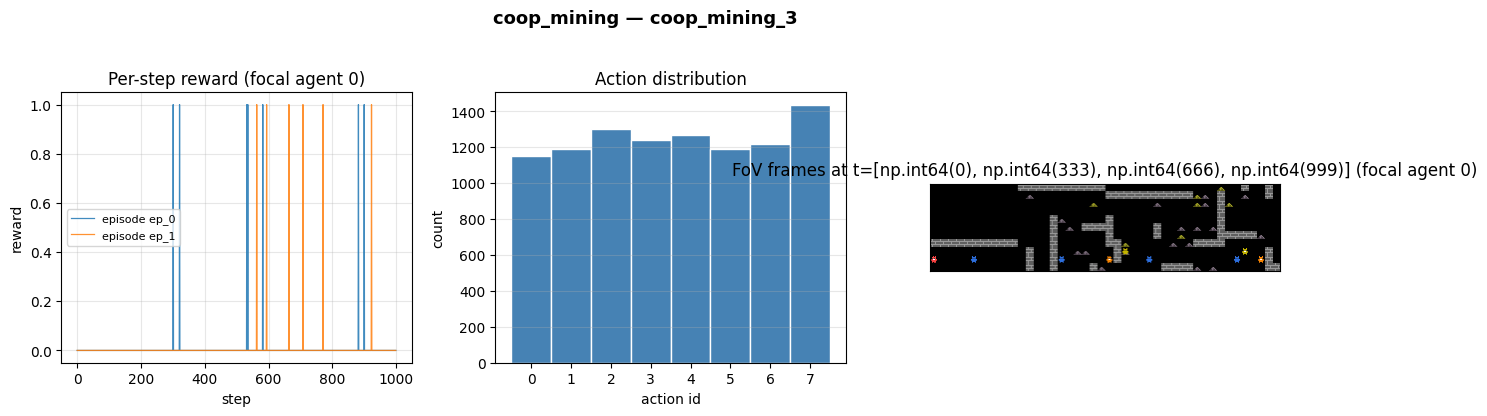

===                           CLEAN_UP                           ===
file: jcformanek/moltenpot:tiny-demo-datasets/clean_up/clean_up_13/dataset.hdf5
size on disk: 11372.1 KB
scenario(s): ['clean_up_13']
  clean_up_13: 2 episodes (['ep_0', 'ep_1'])
    ep_0: T=1000 A= 3  focal-agent returns=[116.0, 1.0, 3.0]
    ep_1: T=1000 A= 3  focal-agent returns=[88.0, 94.0, 15.0]


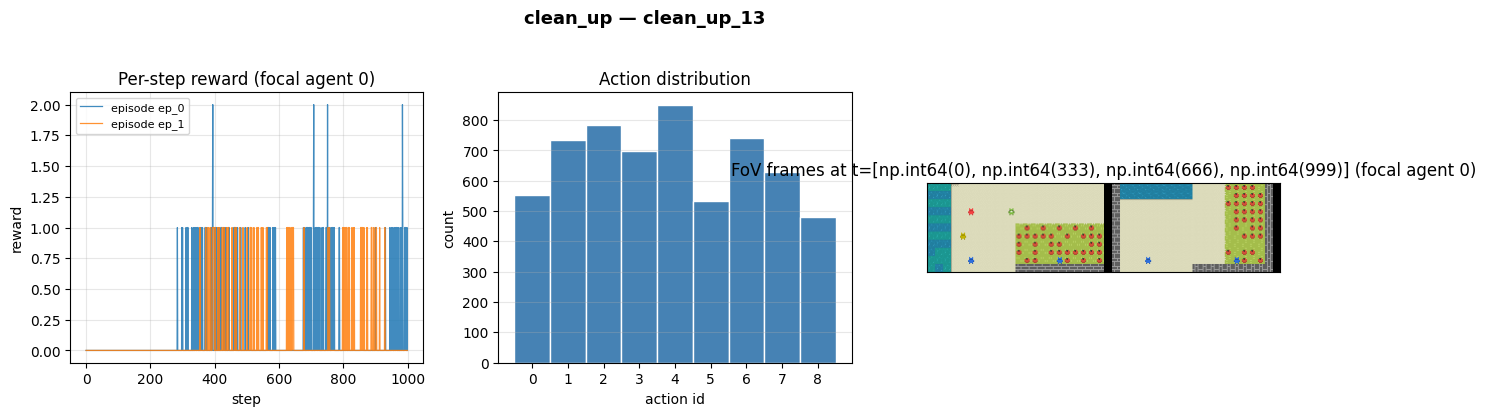

===                       COMMONS_HARVEST                        ===
file: jcformanek/moltenpot:tiny-demo-datasets/commons_harvest/commons_harvest__closed_0/dataset.hdf5
size on disk: 5287.1 KB
scenario(s): ['commons_harvest__closed_0']
  commons_harvest__closed_0: 2 episodes (['ep_0', 'ep_1'])
    ep_0: T=1000 A= 2  focal-agent returns=[0.0, 7.0]
    ep_1: T=1000 A= 2  focal-agent returns=[0.0, 6.0]


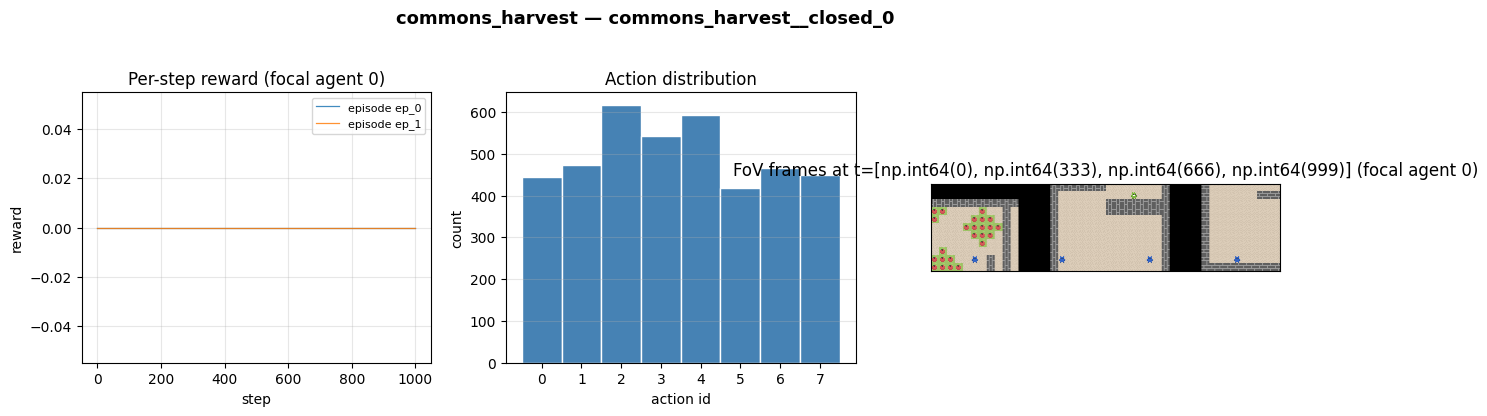

===                     ALLELOPATHIC_HARVEST                     ===
file: jcformanek/moltenpot:tiny-demo-datasets/allelopathic_harvest/allelopathic_harvest__open_4/dataset.hdf5
size on disk: 27312.2 KB
scenario(s): ['allelopathic_harvest__open_4']
  allelopathic_harvest__open_4: 2 episodes (['ep_0', 'ep_1'])
    ep_0: T=1000 A= 8  focal-agent returns=[-7.0, -36.0, -16.0, 12.0, -16.0, -3.0, -20.0, 0.0]
    ep_1: T=1000 A= 8  focal-agent returns=[3.0, -2.0, -18.0, 10.0, 2.0, 3.0, -8.0, -4.0]


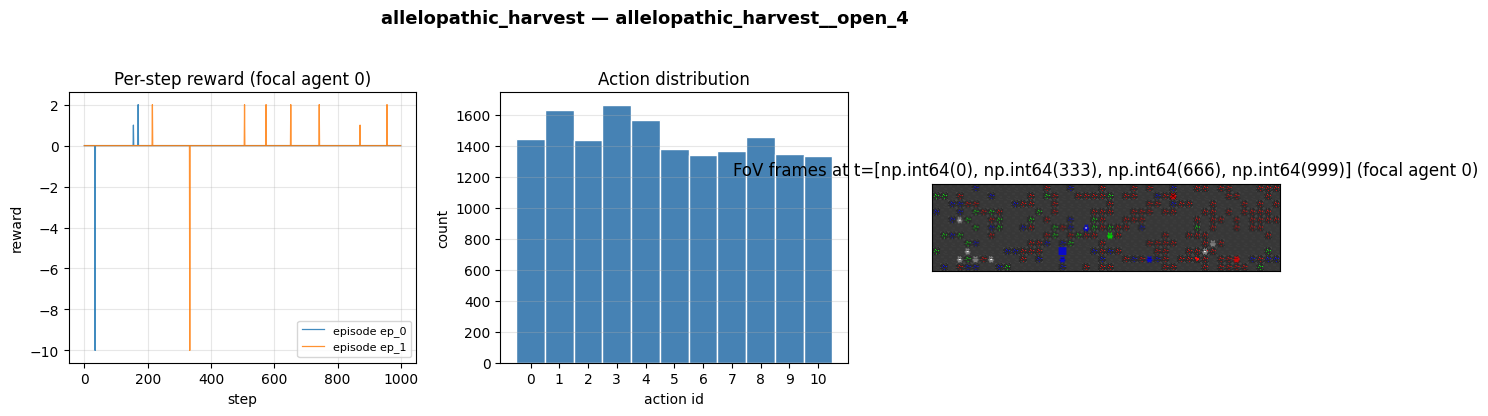

In [6]:
all_paths: dict[str, Path] = {}
for s in SUBSTRATES:
    p = resolve_dataset(s)
    if p is None:
        print(f"[skip] {s}: no dataset found.")
        continue
    all_paths[s] = p
    summarise(s, p)
    plot_substrate_panel(s, p)
    print()

## 3. Cross-substrate summary

A quick comparison of episode-return distributions across the five
substrates. Each substrate's tiny dataset has only two episodes, so
this is a rough qualitative cross-check rather than a statistical
summary — the full per-scenario histograms (1000 episodes each) are
available in the
[scenario browser](https://jcformanek.github.io/moltenpot/).


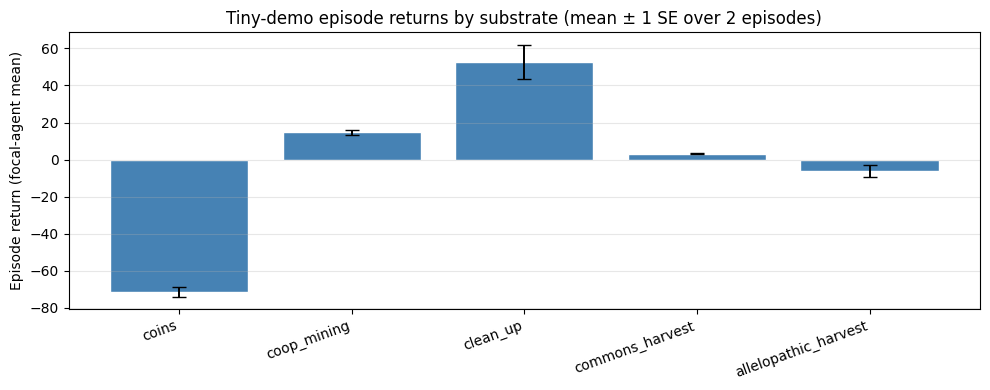

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
returns_by_sub: dict[str, list[float]] = {}
for substrate, path in all_paths.items():
    rs: list[float] = []
    with h5py.File(path, "r") as f:
        scen = list(f.keys())[0]
        for ep_k in f[scen]:
            ep_rewards = f[scen][ep_k]["rewards"][...]      # (T, A)
            # Episode return per focal agent, averaged across agents.
            rs.append(float(ep_rewards.sum(axis=0).mean()))
    returns_by_sub[substrate] = rs

xs = list(returns_by_sub.keys())
means = [np.mean(returns_by_sub[s]) for s in xs]
sems  = [np.std(returns_by_sub[s], ddof=0) / np.sqrt(len(returns_by_sub[s]))
         for s in xs]
ax.bar(xs, means, yerr=sems, color="steelblue", edgecolor="white",
       capsize=5, error_kw={"elinewidth": 1.4})
ax.set_ylabel("Episode return (focal-agent mean)")
ax.set_title("Tiny-demo episode returns by substrate (mean ± 1 SE over 2 episodes)")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=20, ha="right")
plt.tight_layout(); plt.show()

That is the entire tiny dataset surface area. To work with the full
~1 TB corpus, see the [`README`](../README.md) — every offline-RL
training run auto-downloads the matching scenarios from
[`jcformanek/moltenpot`](https://huggingface.co/datasets/jcformanek/moltenpot)
on first use.
